In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("DelayedFlights_Sample.csv")

In [25]:
df.head()


,Year,Month,DayofMonth,DayOfWeek,UniqueCarrier,FlightNum,TailNum,CRSElapsedTime,Origin,Dest,Distance,FlightDate,WeekOfYear,ArrDelay15,DepDelay15,DepHour,DepMin,ArrHour,ArrMin
0,2008,1,14,1,WN,23,N640SW,60.0,DAL,HOU,239,2008-01-14,3,0,0,12,0,13,0
1,2008,1,14,1,WN,47,N501SW,60.0,DAL,HOU,239,2008-01-14,3,0,0,18,0,19,0
2,2008,1,14,1,WN,54,N520SW,65.0,DAL,LBB,293,2008-01-14,3,1,1,20,50,21,55
3,2008,1,14,1,WN,34,N613SW,70.0,DAL,MAF,319,2008-01-14,3,0,0,15,50,17,0
4,2008,1,14,1,WN,36,N314SW,55.0,HOU,DAL,239,2008-01-14,3,0,0,15,0,15,55


In [26]:
df["ArrDelay15"].value_counts()

ArrDelay15
1    44371
0    26998
Name: count, dtype: int64

In [27]:
df["DepDelay15"].value_counts()

DepDelay15
1    46934
0    24435
Name: count, dtype: int64

## Macierz korelacji 


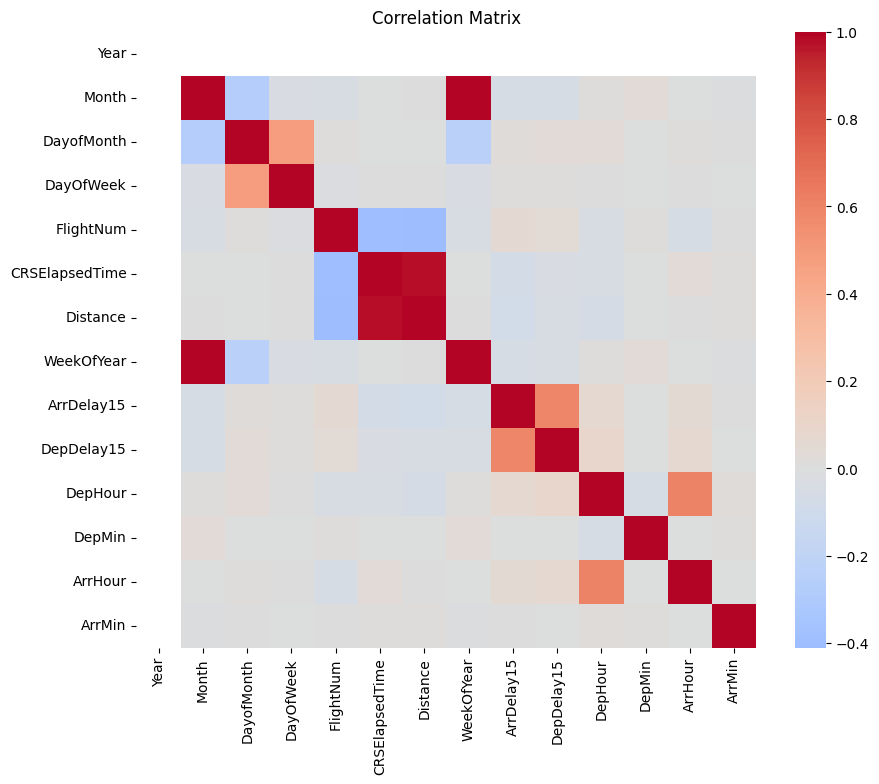

In [ ]:
numeric_df = df.select_dtypes(include=["int64","float64"])

corr = numeric_df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

## Analiza składowych

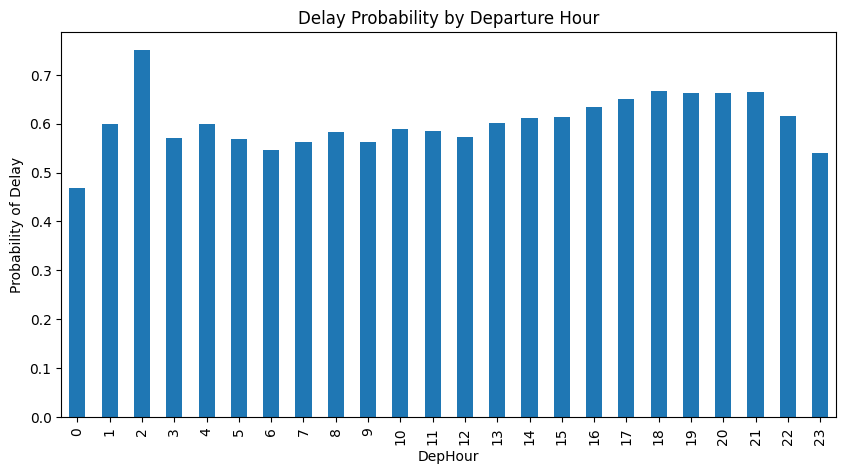

In [30]:
delay_by_hour = df.groupby("DepHour")["ArrDelay15"].mean()

delay_by_hour.plot(kind="bar", figsize=(10,5))
plt.title("Delay Probability by Departure Hour")
plt.ylabel("Probability of Delay")
plt.show()

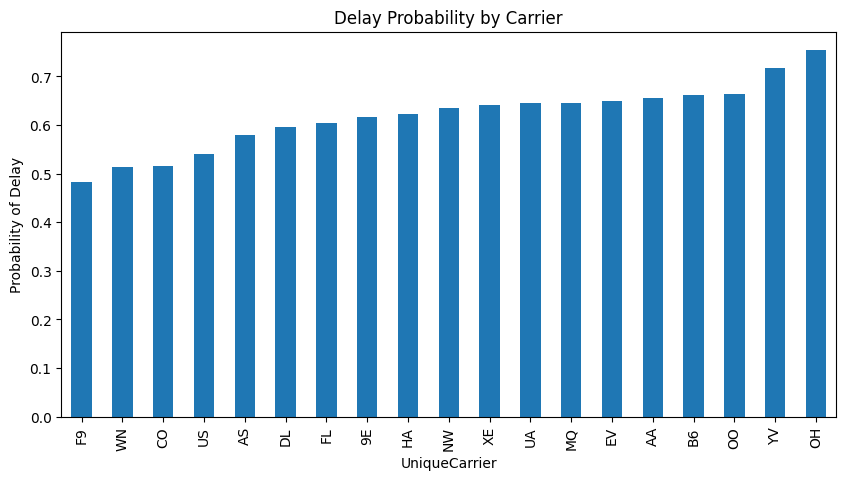

In [31]:
delay_by_carrier = df.groupby("UniqueCarrier")["ArrDelay15"].mean().sort_values()

delay_by_carrier.plot(kind="bar", figsize=(10,5))
plt.title("Delay Probability by Carrier")
plt.ylabel("Probability of Delay")
plt.show()

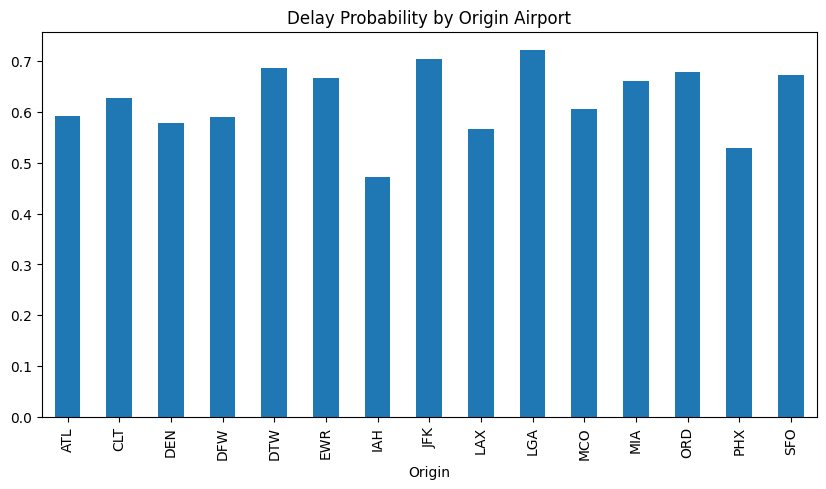

In [32]:
top_airports = df["Origin"].value_counts().head(15).index

airport_df = df[df["Origin"].isin(top_airports)]

delay_by_airport = airport_df.groupby("Origin")["ArrDelay15"].mean()

delay_by_airport.plot(kind="bar", figsize=(10,5))
plt.title("Delay Probability by Origin Airport")
plt.show()

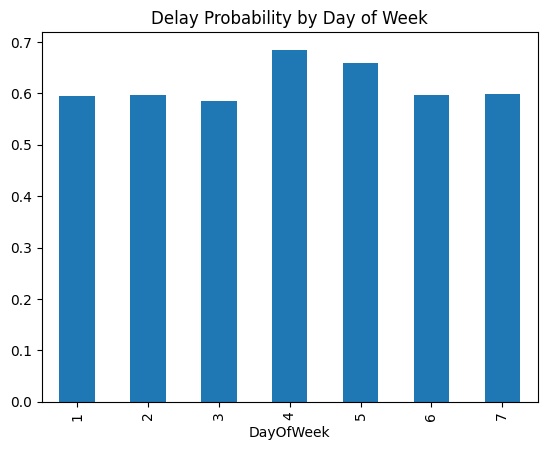

In [33]:
delay_by_day = df.groupby("DayOfWeek")["ArrDelay15"].mean()

delay_by_day.plot(kind="bar")
plt.title("Delay Probability by Day of Week")
plt.show()

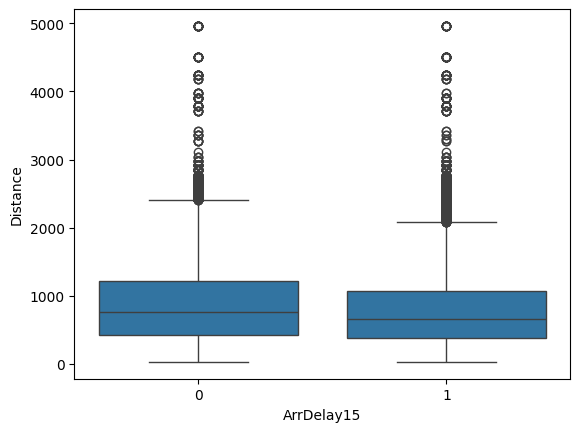

In [34]:
sns.boxplot(x="ArrDelay15", y="Distance", data=df)
plt.show()

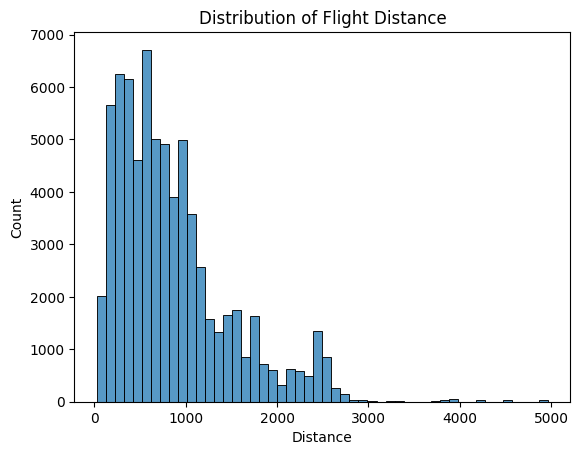

In [35]:
sns.histplot(df["Distance"], bins=50)
plt.title("Distribution of Flight Distance")
plt.show()